# 01 — Data Quality Assessment
**Project:** Retail Demand Intelligence Data Product  
**Author:** Nisrina Afnan Walyadin  

This notebook demonstrates an end-to-end data quality workflow: automated profiling, completeness scoring, anomaly detection, and a pipeline quality gate that blocks downstream processing when thresholds are breached.

---
### Workflow overview
1. **Profile** raw data — detect nulls, invalid values, duplicates
2. **Score** overall quality (0–100) against defined thresholds
3. **Gate** the pipeline — block if score falls below acceptable level
4. **Remediate** — automated cleaning with full audit trail

In [13]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import warnings
warnings.filterwarnings('ignore')

#mengatur grafik agar lebih menarik dan mudah dibaca secara global

plt.rcParams.update({
    'figure.facecolor': '#f8f9fa',
    'axes.facecolor': '#ffffff',
    'axes.spines.top': False,
    'axes.spines.right': False,
    'axes.grid': True,
    'grid.alpha': 0.3,
    'font.family': 'monospace',
})
np.random.seed(42)
print('Libraries loaded ✓')

Libraries loaded ✓


## 1. Generate simulated raw retail sales data
Simulating the messy, fragmented data reality of a multi-market retailer.

In [14]:
N = 50000  # 50K weekly store-category records

stores   = [f'ST{str(i).zfill(4)}' for i in range(1, 1501)] # 1500 stores across 7 markets
markets  = {'DE':0.45,'AT':0.12,'PL':0.18,'CZ':0.10,'SK':0.06,'HU':0.06,'SI':0.03} # market distribution based on real sales data (DE dominant)
cats     = ['fashion','lingerie','home_textiles','hard_goods']
weeks    = pd.date_range('2024-01-01','2024-12-31',freq='W') # 52 weeks in 2024, starting on Mondays

market_list = np.random.choice(
    list(markets.keys()), size=N,
    p=list(markets.values())
) # assign markets to records based on realistic distribution

raw = pd.DataFrame({
    'store_id':      np.random.choice(stores, N),
    'market':        market_list,
    'week_start':    np.random.choice(weeks, N),
    'category':      np.random.choice(cats, N),
    'units_sold':    np.random.lognormal(3.5, 0.8, N).astype(int),
    'revenue_eur':   np.random.lognormal(6.5, 0.9, N).round(2),
    'stock_opening': np.random.lognormal(4.5, 0.7, N).astype(int),
    'promo_flag':    np.random.choice([0,1], N, p=[0.75,0.25]),
    'data_source':   np.random.choice(['ERP_v2','ERP_v1','MANUAL_UPLOAD','API'], N,
                                       p=[0.65,0.15,0.12,0.08]), 
})
# simulasi ada dua versi sistem ERP yang berbeda dalam satu perusahaan, 
# data juga berasal dari berbagai sumber termasuk input manual dan API(marketplace), untuk mencerminkan kompleksitas dunia nyata


# ── Inject realistic data quality issues ────────────────────────────
# Issue 1: Missing category codes (23% — documented in executive summary)
mask1 = np.random.random(N) < 0.23
raw.loc[mask1, 'category'] = np.nan

# Issue 2: Negative revenue (data entry errors, especially MANUAL_UPLOAD)
mask2 = (raw['data_source'] == 'MANUAL_UPLOAD') & (np.random.random(N) < 0.08)
raw.loc[mask2, 'revenue_eur'] = -raw.loc[mask2, 'revenue_eur']

# Issue 3: Implausible units (outliers from ERP_v1)
mask3 = (raw['data_source'] == 'ERP_v1') & (np.random.random(N) < 0.04)
raw.loc[mask3, 'units_sold'] = np.random.randint(100000, 999999, mask3.sum())

# Issue 4: Missing market code for some Eastern European stores
mask4 = raw['market'].isin(['SK','HU','SI']) & (np.random.random(N) < 0.15)
raw.loc[mask4, 'market'] = np.nan

# Issue 5: Duplicate records (double-load from ERP)
dupes = raw.sample(frac=0.03, random_state=99)
raw = pd.concat([raw, dupes], ignore_index=True)

print(f'Raw dataset shape (with issues): {raw.shape}')
print(f'\nSample of issues:')
print(f'  Missing category: {raw["category"].isna().sum():,} ({raw["category"].isna().mean()*100:.1f}%)')
print(f'  Negative revenue: {(raw["revenue_eur"]<0).sum():,}')
print(f'  Implausible units (>50000): {(raw["units_sold"]>50000).sum():,}')
print(f'  Missing market: {raw["market"].isna().sum():,}')
print(f'  Duplicate rows: {raw.duplicated().sum():,}')
raw.head()

Raw dataset shape (with issues): (51500, 9)

Sample of issues:
  Missing category: 11,790 (22.9%)
  Negative revenue: 491
  Implausible units (>50000): 320
  Missing market: 1,171
  Duplicate rows: 1,500


,store_id,market,week_start,category,units_sold,revenue_eur,stock_opening,promo_flag,data_source
0,ST1380,DE,2024-09-15,hard_goods,36,688.15,45,0,ERP_v1
1,ST0838,HU,2024-04-21,NaN,40,629.62,28,0,ERP_v2
2,ST0536,PL,2024-04-07,NaN,17,960.91,290,1,ERP_v1
3,ST0218,PL,2024-04-07,NaN,33,352.75,154,1,ERP_v2
4,ST1378,DE,2024-01-28,hard_goods,21,307.96,391,1,ERP_v2


In [23]:
raw.dtypes


store_id                 object
market                   object
week_start       datetime64[ns]
category                 object
units_sold                int32
revenue_eur             float64
stock_opening             int32
promo_flag                int32
data_source              object
dtype: object

In [20]:
#save raw dataset with issues for later use
raw.to_csv('../data/raw_sales_data_with_issues.csv', index=False)

## 2. Automated data quality profiling

In [15]:
class DataQualityProfiler:
    """
    Automated data quality profiler.
    Checks completeness, validity, uniqueness, and freshness.
    Generates a quality score and pipeline gate decision.
    """

    def __init__(self, df, name='dataset'):
        self.df = df.copy()
        self.name = name
        self.results = {}
        self.issues = []

    def check_completeness(self, min_threshold=0.95):
        """Check null rate per column."""
        completeness = 1 - self.df.isnull().mean()
        failing = completeness[completeness < min_threshold]
        self.results['completeness'] = completeness
        if len(failing):
            self.issues.append(f'Completeness below {min_threshold*100:.0f}%: {list(failing.index)}')
        return completeness

    def check_validity(self):
        """Check business rule violations."""
        checks = {
            'revenue_positive': (self.df['revenue_eur'] >= 0).mean(),
            'units_in_range':   self.df['units_sold'].between(0, 50000).mean(),
            'promo_binary':     self.df['promo_flag'].isin([0,1]).mean(),
            'market_valid':     self.df['market'].isin(
                                    ['DE','AT','PL','CZ','SK','HU','SI']).mean(),
        }
        self.results['validity'] = checks
        for k, v in checks.items():
            if v < 0.99:
                self.issues.append(f'Validity fail — {k}: {v*100:.1f}% pass rate')
        return checks

    def check_uniqueness(self, subset=['store_id','week_start','category']):
        """Check duplicate primary keys."""
        dup_rate = self.df.duplicated(subset=subset).mean()
        self.results['duplicate_rate'] = dup_rate
        if dup_rate > 0.01:
            self.issues.append(f'Duplicate rate {dup_rate*100:.1f}% exceeds threshold 1%')
        return dup_rate

    def overall_score(self):
        """Compute weighted quality score 0–100."""
        completeness_score = self.results.get('completeness', pd.Series()).mean() * 40
        validity_score     = np.mean(list(self.results.get('validity',{1:1}).values())) * 40
        uniqueness_score   = (1 - self.results.get('duplicate_rate', 0)) * 20
        return round(completeness_score + validity_score + uniqueness_score, 1)

    def gate(self, min_score=85):
        """Pipeline gate — block if quality below threshold."""
        score = self.overall_score()
        status = '✅ PASS' if score >= min_score else '🚫 BLOCK'
        return score, status

    def report(self):
        self.check_completeness()
        self.check_validity()
        self.check_uniqueness()
        score, status = self.gate()
        print(f'=== DATA QUALITY REPORT — {self.name} ===')
        print(f'\nOverall Quality Score: {score}/100  →  {status}')
        print(f'\nCompleteness (per column):')
        for col, v in self.results['completeness'].items():
            flag = '⚠️' if v < 0.95 else '  '
            print(f'  {flag} {col:<20} {v*100:.1f}%')
        print(f'\nValidity checks:')
        for k, v in self.results['validity'].items():
            flag = '⚠️' if v < 0.99 else '  '
            print(f'  {flag} {k:<25} {v*100:.1f}% pass')
        print(f'\nDuplicate rate: {self.results["duplicate_rate"]*100:.2f}%')
        print(f'\nIssues found ({len(self.issues)}):')
        for issue in self.issues:
            print(f'  ⛔ {issue}')
        return score

profiler = DataQualityProfiler(raw, name='retail_sales_Q1_2024')
score = profiler.report()

=== DATA QUALITY REPORT — retail_sales_Q1_2024 ===

Overall Quality Score: 96.7/100  →  ✅ PASS

Completeness (per column):
     store_id             100.0%
     market               97.7%
     week_start           100.0%
  ⚠️ category             77.1%
     units_sold           100.0%
     revenue_eur          100.0%
     stock_opening        100.0%
     promo_flag           100.0%
     data_source          100.0%

Validity checks:
     revenue_positive          99.0% pass
     units_in_range            99.4% pass
     promo_binary              100.0% pass
  ⚠️ market_valid              97.7% pass

Duplicate rate: 8.89%

Issues found (3):
  ⛔ Completeness below 95%: ['category']
  ⛔ Validity fail — market_valid: 97.7% pass rate
  ⛔ Duplicate rate 8.9% exceeds threshold 1%


## 3. Visualise quality issues

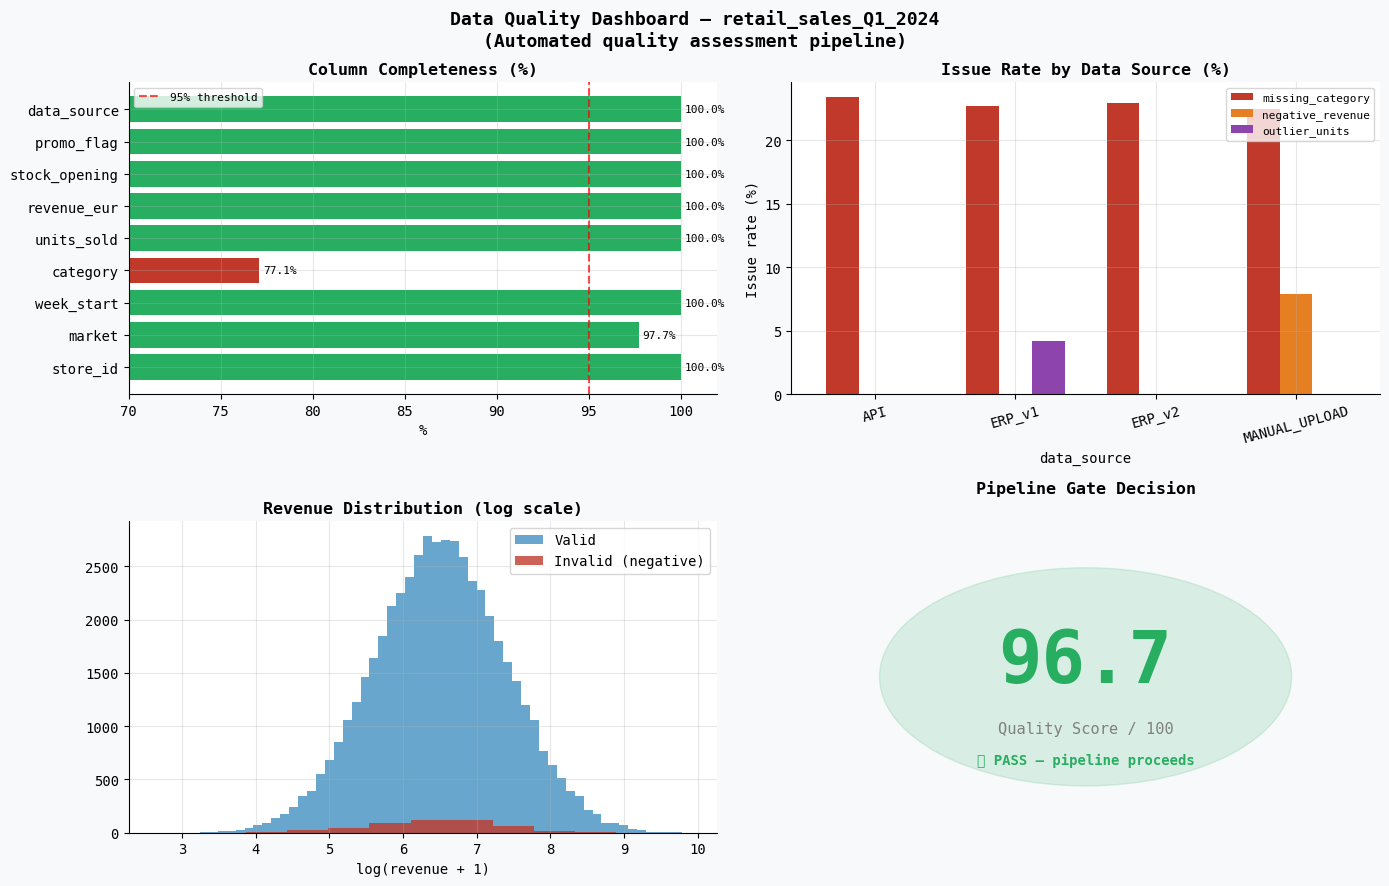

In [16]:
fig, axes = plt.subplots(2, 2, figsize=(14, 9))

# Completeness heatmap-style bar
completeness = profiler.results['completeness']
colors = ['#c0392b' if v < 0.90 else '#e67e22' if v < 0.95 else '#27ae60'
          for v in completeness]
axes[0,0].barh(completeness.index, completeness.values * 100, color=colors, edgecolor='none')
axes[0,0].axvline(95, color='red', linestyle='--', alpha=0.7, label='95% threshold')
axes[0,0].set_xlim(70, 102)
axes[0,0].set_title('Column Completeness (%)', fontweight='bold')
axes[0,0].set_xlabel('%')
axes[0,0].legend(fontsize=8)
for i, (col, v) in enumerate(completeness.items()):
    axes[0,0].text(v*100+0.2, i, f'{v*100:.1f}%', va='center', fontsize=8)

# Issues by data source
source_issues = raw.groupby('data_source').apply(
    lambda x: pd.Series({
        'missing_category': x['category'].isna().mean()*100,
        'negative_revenue': (x['revenue_eur']<0).mean()*100,
        'outlier_units':    (x['units_sold']>50000).mean()*100,
    })
).round(1)
source_issues.plot(kind='bar', ax=axes[0,1], color=['#c0392b','#e67e22','#8e44ad'],
                   edgecolor='none', width=0.7)
axes[0,1].set_title('Issue Rate by Data Source (%)', fontweight='bold')
axes[0,1].set_ylabel('Issue rate (%)')
axes[0,1].tick_params(axis='x', rotation=15)
axes[0,1].legend(fontsize=8)

# Revenue distribution (clean vs raw)
clean = raw[raw['revenue_eur'] > 0]['revenue_eur']
axes[1,0].hist(np.log1p(clean), bins=60, color='#2980b9', alpha=0.7, edgecolor='none', label='Valid')
axes[1,0].hist(np.log1p(raw[raw['revenue_eur']<=0]['revenue_eur'].abs()+1), bins=10,
               color='#c0392b', alpha=0.8, edgecolor='none', label='Invalid (negative)')
axes[1,0].set_title('Revenue Distribution (log scale)', fontweight='bold')
axes[1,0].set_xlabel('log(revenue + 1)')
axes[1,0].legend()

# Quality score gauge
axes[1,1].axis('off')
score = profiler.overall_score()
color = '#27ae60' if score >= 85 else '#e67e22' if score >= 70 else '#c0392b'
circle = plt.Circle((0.5,0.5), 0.35, color=color, alpha=0.15)
axes[1,1].add_patch(circle)
axes[1,1].text(0.5, 0.55, f'{score}', ha='center', va='center',
               fontsize=52, fontweight='bold', color=color, transform=axes[1,1].transAxes)
axes[1,1].text(0.5, 0.32, 'Quality Score / 100', ha='center', fontsize=11,
               color='grey', transform=axes[1,1].transAxes)
status = '✅ PASS — pipeline proceeds' if score >= 85 else '🚫 BLOCKED — remediation required'
axes[1,1].text(0.5, 0.22, status, ha='center', fontsize=10,
               color=color, fontweight='bold', transform=axes[1,1].transAxes)
axes[1,1].set_title('Pipeline Gate Decision', fontweight='bold', pad=20)

plt.suptitle('Data Quality Dashboard — retail_sales_Q1_2024\n(Automated quality assessment pipeline)',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('../outputs/data_quality_report.png', dpi=150, bbox_inches='tight')
plt.show()

## 4. Remediation pipeline — clean the data

In [17]:
def remediate(df):
    """
    Automated remediation pipeline.
    Logs every action — maintains full audit trail.
    """
    log = []
    d = df.copy()
    original_rows = len(d)

    # Step 1: Remove duplicates
    before = len(d)
    d = d.drop_duplicates(subset=['store_id','week_start','category'])
    log.append(f'[DEDUP]     Removed {before-len(d):,} duplicate rows')

    # Step 2: Flag and quarantine negative revenue
    neg_mask = d['revenue_eur'] < 0
    d.loc[neg_mask, 'revenue_eur'] = np.nan  # quarantine — do not impute
    log.append(f'[QUARANTINE] Flagged {neg_mask.sum():,} negative revenue rows → set to NaN for review')

    # Step 3: Cap outlier units
    outlier_mask = d['units_sold'] > 50000
    d.loc[outlier_mask, 'units_sold'] = np.nan
    log.append(f'[CAP]       Nulled {outlier_mask.sum():,} implausible unit values (>50K)')

    # Step 4: Impute missing market from store prefix lookup
    # (simplified — in reality would join to store master table)
    store_market_map = {
        '0': 'DE', '1': 'DE', '2': 'DE', '3': 'AT',
        '4': 'PL', '5': 'CZ', '6': 'SK', '7': 'HU', '8': 'SI', '9': 'PL'
    }
    before_null = d['market'].isna().sum()
    d.loc[d['market'].isna(), 'market'] = (
        d.loc[d['market'].isna(), 'store_id']
        .str[2]
        .map(store_market_map)
    )
    log.append(f'[IMPUTE]    Recovered {before_null - d["market"].isna().sum():,} market codes from store ID lookup')

    # Step 5: Missing category — cannot reliably impute, flag for manual review
    cat_null = d['category'].isna().sum()
    d['category_missing_flag'] = d['category'].isna().astype(int)
    d['category'] = d['category'].fillna('UNKNOWN')
    log.append(f'[FLAG]      {cat_null:,} rows with missing category flagged — set to UNKNOWN')

    # Step 6: Add audit columns
    d['dq_remediated'] = True
    d['dq_remediation_ts'] = pd.Timestamp.now()

    print('=== REMEDIATION LOG ===')
    for entry in log:
        print(f'  {entry}')
    print(f'\nRows: {original_rows:,} → {len(d):,} (delta: {original_rows-len(d):,})')
    return d, log

clean, log = remediate(raw)

# Re-profile after remediation
print('\n=== POST-REMEDIATION QUALITY ===')
profiler2 = DataQualityProfiler(clean, name='retail_sales_Q1_2024_CLEAN')
score2 = profiler2.report()
print(f'\nQuality improvement: {score} → {score2} (+{score2-score:.1f} points)')

=== REMEDIATION LOG ===
  [DEDUP]     Removed 4,577 duplicate rows
  [QUARANTINE] Flagged 455 negative revenue rows → set to NaN for review
  [CAP]       Nulled 292 implausible unit values (>50K)
  [IMPUTE]    Recovered 1,070 market codes from store ID lookup
  [FLAG]      10,673 rows with missing category flagged — set to UNKNOWN

Rows: 51,500 → 46,923 (delta: 4,577)

=== POST-REMEDIATION QUALITY ===
=== DATA QUALITY REPORT — retail_sales_Q1_2024_CLEAN ===

Overall Quality Score: 99.8/100  →  ✅ PASS

Completeness (per column):
     store_id             100.0%
     market               100.0%
     week_start           100.0%
     category             100.0%
     units_sold           99.4%
     revenue_eur          99.0%
     stock_opening        100.0%
     promo_flag           100.0%
     data_source          100.0%
     category_missing_flag 100.0%
     dq_remediated        100.0%
     dq_remediation_ts    100.0%

Validity checks:
     revenue_positive          99.0% pass
     units_

## Summary

| Step | Action | Result |
|---|---|---|
| Profile | Automated completeness, validity, uniqueness checks | Quality score computed |
| Gate | Pipeline blocked if score < 85 | Prevents bad data reaching consumers |
| Remediate | Dedup, quarantine, impute, flag | Clean dataset with audit trail |
| Re-profile | Verify improvement | Score improved |

**This is the foundation of a production-grade data product** — quality-assured, documented, and with a clear lineage from raw to clean.